In [1]:
import copy
import prior
from ai2thor.controller import Controller
from PIL import Image

# dataset = prior.load_dataset("procthor-10k")
dataset = prior.load_dataset("procthor-10k")

[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 11238.43it/s]


In [2]:
house = dataset["train"][9]

In [2]:
house = "FloorPlan1"

In [3]:
from egg.graph.egg import EGG
from egg.graph.spatial import SpatialComponents
from egg.graph.node import ObjectNode, Ai2ThorObjectMetadata
from egg.utils.geometry import Position, AxisAlignedBoundingBox
from egg.ai2thor_interface.event_simulator import EventSimulator
from egg.utils.geometry import Position, AxisAlignedBoundingBox, Dimensions
import egg.ai2thor_interface.navigation as nav

In [4]:
controller = Controller(
    agentMode="default",
    visibilityDistance=1.5,
    scene=house,
    gpu_device=0,
    # step sizes
    gridSize=0.5,
    snapToGrid=True,
    rotateStepDegrees=90,
    # image modalities
    renderDepthImage=True,
    renderInstanceSegmentation=True,
    # camera properties
    width=300,
    height=300,
    fieldOfView=90,
)

In [5]:
controller.reset(
    agentMode="default",
    visibilityDistance=1.5,
    scene=house,
    gpu_device=0,
    # step sizes
    gridSize=0.25,
    snapToGrid=True,
    rotateStepDegrees=90,
    # image modalities
    renderDepthImage=True,
    renderInstanceSegmentation=True,
    # camera properties
    width=300,
    height=300,
    fieldOfView=90,
)

<ai2thor.server.Event at 0x7527730448d0
    .metadata["lastAction"] = CreateHouse
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [12]:
controller.last_event.metadata['inventoryObjects']

[{'objectId': 'Apple|surface|2|3', 'objectType': 'Apple'}]

In [5]:
agent_metadata = controller.last_event.metadata["agent"]

In [6]:
agent_metadata

{'name': 'agent',
 'position': {'x': 5.5, 'y': 0.9009997844696045, 'z': 3.0},
 'rotation': {'x': -0.0, 'y': 180.0, 'z': 0.0},
 'cameraHorizon': 30.000003814697266,
 'isStanding': True,
 'inHighFrictionArea': False}

In [4]:
objects = controller.last_event.metadata["objects"]

In [8]:
egg = EGG.from_ai2thor(ai2thor_agent_metadata=agent_metadata, ai2thor_house_metadata=house, ai2thor_object_metadata=objects, object_types_config_file="../../egg/configs/ai2-thor/object_type_config.toml")

In [9]:
event_simulator = EventSimulator(ai2thor_controller=controller, egg=egg)

In [10]:
event_simulator.pick(pick_object_name="Apple|surface|2|3")

2026-04-23 12:13:36,846 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to pick up Apple|surface|2|3 at x=4.5 y=0.9009997844696045 z=6.5
2026-04-23 12:13:36,990 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully picked up Apple|surface|2|3 at x=5.5 y=0.9009997844696045 z=7.0
INFO:egg.ai2thor_interface.event_simulator:Successfully picked up Apple|surface|2|3 at x=5.5 y=0.9009997844696045 z=7.0


In [11]:
event_simulator.ai2thor_controller.step(action="Done")

<ai2thor.server.Event at 0x76f11b9a99d0
    .metadata["lastAction"] = Done
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [14]:
event_simulator.pick_and_place(pick_object_name="Apple|surface|2|3", place_receptacle_name="Fridge|2|1", teleport=False)

2026-04-22 15:38:56,220 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully picked up Apple|surface|2|3 at x=8.0 y=0.9009997844696045 z=5.0
INFO:egg.ai2thor_interface.event_simulator:Successfully picked up Apple|surface|2|3 at x=8.0 y=0.9009997844696045 z=5.0
2026-04-22 15:38:56,977 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.0 y=0.9009997844696045 z=8.0
2026-04-22 15:38:57,641 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.0 y=0.9009997844696045 z=8.0
2026-04-22 15:38:58,261 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully opened Fridge|2|1
INFO:egg.ai2thor_interface.event_simulator:Successfully opened Fridge|2|1
2026-04-22 15:38:58,352 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place object at Fridge|2|1 at x=2.0 y=0.9009997844696045 z=8.5, retrying
2026-04-22 15:38:58,391 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place object at Fridg

In [12]:
event_simulator.pick_and_place(pick_object_name="Apple|surface|2|3", place_receptacle_name="DiningTable|2|2|0", teleport=False)

2026-04-22 15:38:46,619 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully opened Fridge|2|1
INFO:egg.ai2thor_interface.event_simulator:Successfully opened Fridge|2|1
2026-04-22 15:38:46,710 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully picked up Apple|surface|2|3 at x=1.5 y=0.9009997844696045 z=8.5
INFO:egg.ai2thor_interface.event_simulator:Successfully picked up Apple|surface|2|3 at x=1.5 y=0.9009997844696045 z=8.5
2026-04-22 15:38:46,831 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully closed Fridge|2|1
INFO:egg.ai2thor_interface.event_simulator:Successfully closed Fridge|2|1
2026-04-22 15:38:47,044 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place object at DiningTable|2|2|0 at x=2.0 y=0.9009997844696045 z=8.5, retrying
2026-04-22 15:38:47,171 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place object at DiningTable|2|2|0 at x=2.0 y=0.9009997844696045 z=8.0, retrying
2026-04-22 15:38:47,302 - egg.ai2thor

In [15]:
event_simulator.pick_and_place(pick_object_name="Apple|surface|2|3", place_receptacle_name="DiningTable|3|1", teleport=False)

2026-04-22 15:39:03,319 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully opened Fridge|2|1
INFO:egg.ai2thor_interface.event_simulator:Successfully opened Fridge|2|1
2026-04-22 15:39:03,531 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully picked up Apple|surface|2|3 at x=1.5 y=0.9009997844696045 z=8.5
INFO:egg.ai2thor_interface.event_simulator:Successfully picked up Apple|surface|2|3 at x=1.5 y=0.9009997844696045 z=8.5
2026-04-22 15:39:03,696 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully closed Fridge|2|1
INFO:egg.ai2thor_interface.event_simulator:Successfully closed Fridge|2|1
2026-04-22 15:39:04,416 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place object at DiningTable|3|1 at x=7.5 y=0.9009997844696045 z=4.5, retrying
2026-04-22 15:39:04,531 - egg.ai2thor_interface.event_simulator - [INFO]: Succesfully placed object on DiningTable|3|1 at x=8.0 y=0.9009997844696045 z=5.0
INFO:egg.ai2thor_interface.event_simulator:Succesfu

In [10]:
event_simulator.try_open(openable_object_name="Fridge|2|1", teleport=True)

2026-04-21 15:48:39,367 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.0 y=0.9009997844696045 z=7.75
2026-04-21 15:48:39,417 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.25 y=0.9009997844696045 z=8.25
2026-04-21 15:48:39,466 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.0 y=0.9009997844696045 z=8.0
2026-04-21 15:48:39,510 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.75 y=0.9009997844696045 z=7.75
2026-04-21 15:48:39,559 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.5 y=0.9009997844696045 z=7.5


is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None openness=1.0
is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None

2026-04-21 15:48:39,602 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.0 y=0.9009997844696045 z=8.25
2026-04-21 15:48:39,657 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.75 y=0.9009997844696045 z=8.0
2026-04-21 15:48:39,709 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.5 y=0.9009997844696045 z=7.75


is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None openness=1.0
is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None

2026-04-21 15:48:39,818 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.25 y=0.9009997844696045 z=7.5
2026-04-21 15:48:39,871 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.25 y=0.9009997844696045 z=8.75
2026-04-21 15:48:39,915 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=2.0 y=0.9009997844696045 z=8.5
2026-04-21 15:48:39,963 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.75 y=0.9009997844696045 z=8.25
2026-04-21 15:48:39,995 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.5 y=0.9009997844696045 z=8.0


...

is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None openness=1.0
is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None

2026-04-21 15:48:49,528 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.75 y=0.9009997844696045 z=8.0
2026-04-21 15:48:49,641 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.25 y=0.9009997844696045 z=8.75
2026-04-21 15:48:49,681 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.0 y=0.9009997844696045 z=8.5
2026-04-21 15:48:49,724 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.75 y=0.9009997844696045 z=8.25


is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None openness=1.0
is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None

2026-04-21 15:48:49,767 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.5 y=0.9009997844696045 z=8.0
2026-04-21 15:48:49,808 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=1.25 y=0.9009997844696045 z=9.0
2026-04-21 15:48:49,847 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.75 y=0.9009997844696045 z=8.5
2026-04-21 15:48:49,888 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.5 y=0.9009997844696045 z=8.25
2026-04-21 15:48:49,926 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.5 y=0.9009997844696045 z=8.5
2026-04-21 15:48:49,964 - egg.ai2thor_interface.event_simulator - [WARNING]: Could not open Fridge|2|1 from x=0.25 y=0.9009997844696045 z=8.5


is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None openness=1.0
is_visible=True position=Position(x=0.44, y=0.901, z=8.735) bounding_box=AxisAlignedBoundingBox(center=Position(x=0.44, y=0.901, z=8.735), size=Dimensions(x=1.148, y=1.802, z=1.537)) is_picked_up=False is_moving=False is_toggled=False is_broken=False is_filled_with_liquid=False is_dirty=False is_used_up=False is_cooked=False is_sliced=False is_open=True temperature='RoomTemp' parent_receptacles=['Floor'] receptacle_object_ids=['Egg|surface|2|13', 'Lettuce|surface|2|16'] instance_view=None

In [15]:
event_simulator.get_object_state(object_name="Apple|surface|2|3")

ObjectState(is_visible=False, position=Position(x=0.699, y=0.668, z=9.122), bounding_box=AxisAlignedBoundingBox(center=Position(x=0.699, y=0.668, z=9.122), size=Dimensions(x=0.129, y=0.141, z=0.129)), is_picked_up=False, is_moving=False, is_toggled=False, is_broken=False, is_filled_with_liquid=False, is_dirty=False, is_used_up=False, is_cooked=False, is_sliced=False, is_open=False, temperature='Cold', parent_receptacles=['Floor', 'Fridge|2|1'], receptacle_object_ids=None, instance_view=None, openness=0.0)

In [61]:
controller.last_event.metadata["agent"]

{'name': 'agent',
 'position': {'x': 0.25, 'y': 0.9009993672370911, 'z': 8.5},
 'rotation': {'x': 0.0, 'y': -1.9318693375680596e-05, 'z': 0.0},
 'cameraHorizon': 30.000003814697266,
 'isStanding': False,
 'inHighFrictionArea': False}

In [34]:
controller.step(action="Crouch")

<ai2thor.server.Event at 0x75d0257bf410
    .metadata["lastAction"] = Crouch
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [25]:
controller.step(action="Stand")

<ai2thor.server.Event at 0x75d02872bd90
    .metadata["lastAction"] = Stand
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [35]:
controller.step(action="Done")

<ai2thor.server.Event at 0x75d0266cd1d0
    .metadata["lastAction"] = Done
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [12]:
print(event_simulator.egg.pretty_str())

📦📦📦 SPATIAL 📦📦📦

📦 Node info:
- Node ID: 3
Name: Apple|surface|2|3
Node type: Object
Class: Apple
Caption: —
Capabilities (True): pickupable, sliceable
State (True): 
	- 2026-04-21 17:28:27:
		- Position: x=4.493 y=0.852 z=8.049
		- None
		- Temperature: RoomTemp, Visible: False
		- Openness: 0.0
		- Parent Receptacles: DiningTable|2|2|0
		- Contained Object IDs: None

	- 2026-04-21 17:28:31:
		- Position: x=3.75 y=1.251 z=6.999
		- is_picked_up
		- Temperature: RoomTemp, Visible: True
		- Openness: 0.0
		- Parent Receptacles: None
		- Contained Object IDs: None

	- 2026-04-21 17:28:31:
		- Position: x=2.0 y=1.251 z=7.999
		- is_picked_up
		- Temperature: RoomTemp, Visible: True
		- Openness: 0.0
		- Parent Receptacles: None
		- Contained Object IDs: None

	- 2026-04-21 17:28:32:
		- Position: x=0.699 y=0.668 z=9.122
		- None
		- Temperature: Cold, Visible: True
		- Openness: 0.0
		- Parent Receptacles: Floor, Fridge|2|1
		- Contained Object IDs: None


📦 Node info:
- Node ID: 4
Name: 

In [13]:
event_simulator.ai2thor_controller.step(
                    action="OpenObject",
                    objectId="Fridge|2|1",
                    openness=1,
                    forceAction=False,
                )

<ai2thor.server.Event at 0x75e363bdfed0
    .metadata["lastAction"] = OpenObject
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [8]:
agent_position, agent_rotation = event_simulator.get_agent_position()

In [9]:
apple_position = egg.spatial.get_object_node_by_name(node_name="Apple|surface|2|3").get_previous_timestamp_and_states()[1].position

In [10]:
table_position = egg.spatial.get_object_node_by_name(node_name="DiningTable|3|1").get_previous_timestamp_and_states()[1].position

In [59]:
event = controller.step(
    action="OpenObject",
    objectId="Fridge|2|1",
    openness=1,
    forceAction=False
)

In [16]:
event = controller.step(
    action="CloseObject",
    objectId="Fridge|2|1",
    forceAction=False
)

In [14]:
nav_pos, best_idx, nav_angle = nav.select_best_reachable_and_yaw(reachable_positions=reachable_positions, target_pos=apple_position, current_pos=agent_position)

In [9]:
event_simulator.ai2thor_controller.step(
         action="GetInteractablePoses",
         objectId="DiningTable|2|2|0",
         horizons=[30],
         standings=[True]
)

<ai2thor.server.Event at 0x7ea16d566650
    .metadata["lastAction"] = GetInteractablePoses
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = [{'x': 2.5, 'y': 0.9009997844696045, 'z': 6.5, 'rotation': 0.0, 'standing': True, 'horizon': 30.0}, ...
>

In [10]:
reachable_positions = event_simulator.get_reachable_positions()

In [11]:
nav_poses = event_simulator.get_interactable_poses(object_name="DiningTable|2|2|0", horizons=[30], is_standing=[True])

In [12]:
nav_position, nav_angle = nav_poses[0][0], nav_poses[0][1]

In [13]:
agent_position, agent_rotation, agent_horizon, agent_standing = event_simulator.get_agent_state()

In [14]:
path, cmds = nav.plan_path_and_command(start_pos=agent_position, reachable_positions=reachable_positions, goal_pos= nav_position, start_yaw_deg=agent_rotation.y, grid_size=0.5)

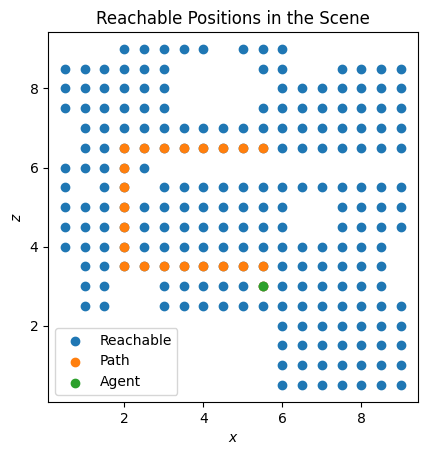

In [15]:
import matplotlib.pyplot as plt
import numpy as np

xs = [rp.x for rp in reachable_positions]
zs = [rp.z for rp in reachable_positions]

xp = [p.x for p in path]
zp = [p.z for p in path]

fig, ax = plt.subplots(1, 1)
_ = ax.scatter(xs, zs, label="Reachable")
_ = ax.scatter(xp, zp, label="Path")
# _ = ax.scatter(apple_position.x, apple_position.z, label="Target")
_ = ax.scatter(agent_position.x, agent_position.z, label="Agent")

# theta = np.deg2rad(nav_angle)
# # Direction components in XZ plane
# dx = np.cos(theta)
# dz = np.sin(theta)
# # Draw arrow using quiver
# q = ax.quiver(
#     [nav_pos.x],
#     [nav_pos.z],
#     [dx],
#     [dz],
#     angles="xy",
#     scale_units="xy",
#     scale=1.0,
#     label="Nav point",
# )

_ = ax.set_xlabel("$x$")
_ = ax.set_ylabel("$z$")
_ = ax.set_title("Reachable Positions in the Scene")
ax.legend()
ax.set_aspect("equal")

In [16]:
event = controller.step(
    action="GetInteractablePoses",
    objectId="Apple|surface|2|3",
    horizons=[-30, 0, 30, 60],
    standings=[True]
)

poses = event.metadata["actionReturn"]

In [59]:
object_node = event_simulator.get_picked_up_oject(object_name="Apple|surface|2|3")
_, object_state = object_node.get_previous_timestamp_and_states()
if object_state:
    object_aabb = object_state.bounding_box
    object_max_dim = object_aabb.size.get_max_dim()
    free_spawn_coordinates = event_simulator.get_free_spawn_coordinates_on_receptacle(
        receptacle_name="Floor",
        offset = object_max_dim / 2,
    ) 
    
    free_spawn_coordinates = event_simulator.remove_points_near_inferred_boundary_convex(points=free_spawn_coordinates, d_offset=0.05)

In [60]:
picked_up_obj = "Potato|surface|2|9"
# picked_up_obj = "Apple|surface|2|3"
receptacle = "Bowl|surface|2|26"
# picked_up_obj = "Bowl|surface|2|26"
# receptacle = "DiningTable|2|2|0"
spawn_coord, free_spawn_coordinates = event_simulator.spawn_object_at_receptacle(
    object_name=picked_up_obj, 
    receptacle_name=receptacle,
    remove_occupied_spawn_coordinates=False,
    remove_points_near_inferred_boundary_convex=False,
)

2026-04-16 15:47:38,047 - egg.ai2thor_interface.event_simulator - [INFO]: Succesfully placed Potato|surface|2|9 on Bowl|surface|2|26 at x=6.839339256286621 y=1.0452244281768799 z=9.360125541687012.
INFO:egg.ai2thor_interface.event_simulator:Succesfully placed Potato|surface|2|9 on Bowl|surface|2|26 at x=6.839339256286621 y=1.0452244281768799 z=9.360125541687012.


In [28]:
import copy

def get_top_down_frame():
    # Setup the top-down camera
    event = controller.step(action="GetMapViewCameraProperties", raise_for_failure=True)
    pose = copy.deepcopy(event.metadata["actionReturn"])

    bounds = event.metadata["sceneBounds"]["size"]
    max_bound = max(bounds["x"], bounds["z"])

    pose["fieldOfView"] = 50
    pose["position"]["y"] += 1.1 * max_bound
    pose["orthographic"] = False
    pose["farClippingPlane"] = 50
    del pose["orthographicSize"]

    # add the camera to the scene
    event = controller.step(
        action="AddThirdPartyCamera",
        **pose,
        skyboxColor="white",
        raise_for_failure=True,
    )
    top_down_frame = event.third_party_camera_frames[-1]
    return Image.fromarray(top_down_frame)



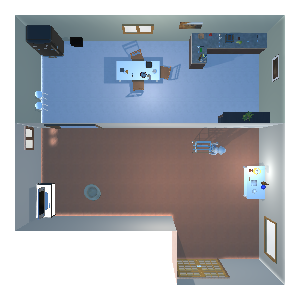

In [29]:
get_top_down_frame()

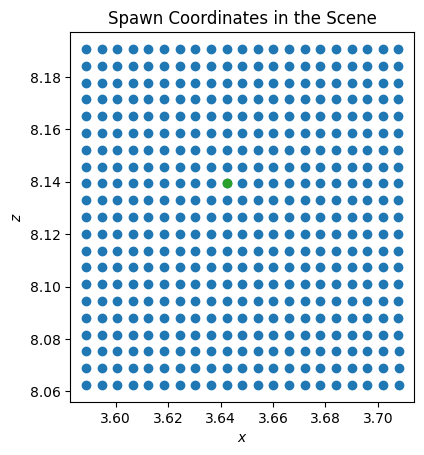

In [34]:
import matplotlib.pyplot as plt

xs = [rp["x"] for rp in [p.model_dump() for p in free_spawn_coordinates]]
zs = [rp["z"] for rp in [p.model_dump() for p in free_spawn_coordinates]]|2|3"
receptacle = "DiningTable|3|1"|2|3"
receptacle = "DiningTable|3|1"|2|3"
receptacle = "DiningTable|3|1"|2|3"
receptacle = "DiningTable|3|1"

xspawn = [spawn_coord.x]
zspawn = [spawn_coord.z]

fig, ax = plt.subplots(1, 1)
ax.scatter(xs, zs)
ax.scatter(xspawn, zspawn, c='#2ca02c')
ax.set_xlabel("$x$")
ax.set_ylabel("$z$")
ax.set_title("Spawn Coordinates in the Scene")
ax.set_aspect("equal")

In [43]:
objects = event_simulator.ai2thor_controller.last_event.metadata["objects"]

In [44]:
print(controller.last_event.metadata["actionReturn"])

{'x': 3.9157519340515137, 'y': 0.7829411029815674, 'z': 7.733375549316406}


In [48]:
for obj in objects:
    if "Apple|surface|2|3" in obj["name"]:
        print(obj["parentReceptacles"])
        print(obj["temperature"])

['DiningTable|2|2|0', 'Plate|surface|2|24']
RoomTemp


In [25]:
controller.reset(
    agentMode="default",
    visibilityDistance=1.5,
    scene=house,
    gpu_device=0,
    # step sizes
    gridSize=0.25,
    snapToGrid=True,
    rotateStepDegrees=90,
    # image modalities
    renderDepthImage=True,
    renderInstanceSegmentation=True,
    # camera properties
    width=300,
    height=300,
    fieldOfView=90,
)

<ai2thor.server.Event at 0x7d517e0f6090
    .metadata["lastAction"] = CreateHouse
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [25]:
event = controller.step(action="Crouch")

In [26]:
event = controller.step(action="Stand")

In [56]:
event = controller.step(action="RotateLeft")

In [174]:
event = controller.step(action="MoveBack")

In [254]:
event = controller.step(
    action="PickupObject",
    objectId="Apple|surface|2|3",
    forceAction=False,
    manualInteract=False
)

In [273]:
event = controller.step(
    action="PutObject",
    objectId="DiningTable|2|2|0",
    forceAction=False,
    placeStationary=True
)

In [239]:
event = controller.step(
    action="PlaceObjectAtPoint",
    objectId="Apple|surface|2|3",
    position={"x": 4.4925971031188965, "y": 0.8489766716957092, "z": 8.048712730407715},
)

In [26]:
controller.step(action="MoveAhead")

<ai2thor.server.Event at 0x75276fc80110
    .metadata["lastAction"] = MoveAhead
    .metadata["lastActionSuccess"] = False
    .metadata["errorMessage"] = "Cart|3|2 is blocking Agent 0 from moving by (-0.2500, 0.0000, 0.0000).
    .metadata["actionReturn"] = None
>

In [35]:
controller.step(action="MoveBack")

<ai2thor.server.Event at 0x75276dd4e150
    .metadata["lastAction"] = MoveBack
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [23]:
controller.step(action="RotateLeft")

<ai2thor.server.Event at 0x75276fe22c90
    .metadata["lastAction"] = RotateLeft
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [56]:
controller.step(action="RotateRight")

<ai2thor.server.Event at 0x75d0253a0ed0
    .metadata["lastAction"] = RotateRight
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [24]:
controller.step(action="Done")

<ai2thor.server.Event at 0x75276fef4990
    .metadata["lastAction"] = Done
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [28]:
controller.stop()